# 02 — Data Quality

**Purpose:** Validate every dimension of the raw dataset before any modelling.
Issues found here must be fixed before proceeding.

Checks performed:
1. Schema validation (required columns + dtypes)
2. Missing values (count, %, impact)
3. Outlier detection (IQR-based)
4. Survival-specific consistency (duration > 0, valid events, event rate)
5. Data leakage heuristic (correlation with target)
6. Minimum sample size

---
**Inputs:** `data/raw/survival_data.parquet`  
**Outputs:** Quality report (printed + visualised) + `data/raw/quality_flag.json`

In [1]:
import sys, json
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import load_data, load_config, DATA_RAW
from src.quality_checks import (
    run_all_checks, print_report,
    plot_missing_heatmap, plot_distributions, plot_survival_overview,
    check_missing_values, check_outliers,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 40)
print('Ready.')

Ready.


In [2]:
cfg = load_config()
DURATION_COL = cfg['target']['duration_col']
EVENT_COL    = cfg['target']['event_col']
NUMERIC_COLS = cfg['numeric_features']

df = load_data('survival_data', stage='raw')
print(f'Shape: {df.shape}')
df.head(3)

Loaded 2,000 rows from /Users/ana/Documents/survival-analysis-pipelines/data/raw/survival_data.parquet
Shape: (2000, 17)


,duration,event,age,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_products,avg_monthly_usage_3m,support_calls_3m,payment_delay_count,login_frequency_30d,charge_per_tenure,support_intensity,usage_trend,product_density
0,1.1,1,23.0,63.0,Two year,Bank transfer,60.99,3779.34,4.0,55.3,0.0,7.0,29.0,0.9681,0.0000,0.376,0.0635
1,1.0,1,62.0,5.0,Month-to-month,Mailed check,30.70,173.10,3.0,84.8,3.0,6.0,25.0,6.1400,0.6000,6.837,0.6000
2,2.4,1,55.0,29.0,Two year,Credit card,NaN,2071.39,2.0,96.5,4.0,2.0,21.0,2.4562,0.1379,-3.633,0.0690


## 1. Survival Target Overview

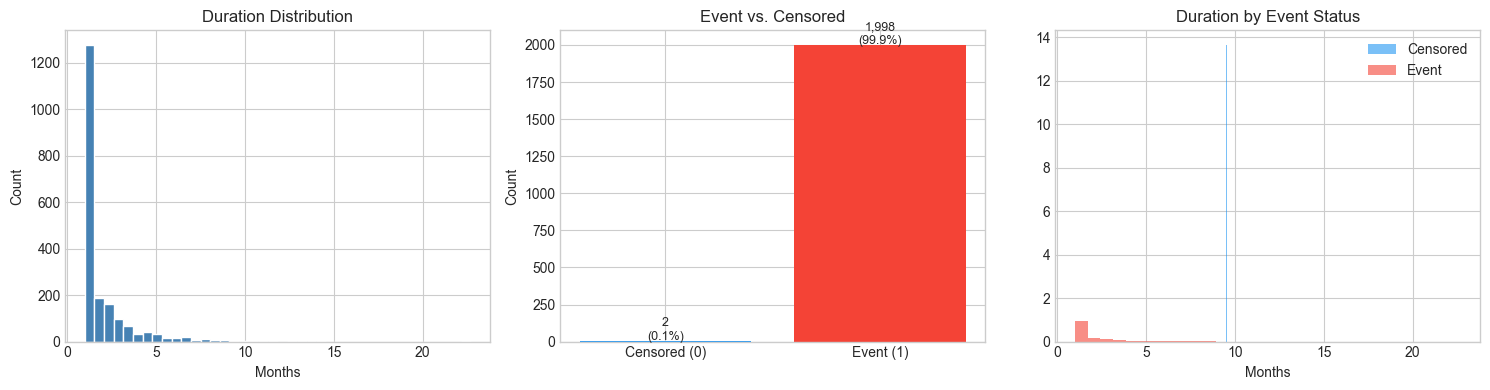

In [3]:
plot_survival_overview(df, DURATION_COL, EVENT_COL)

## 2. Missing Values

Missing value report:


,missing_count,missing_pct
monthly_charges,60,3.0



Suggestion: Missing values within acceptable limits


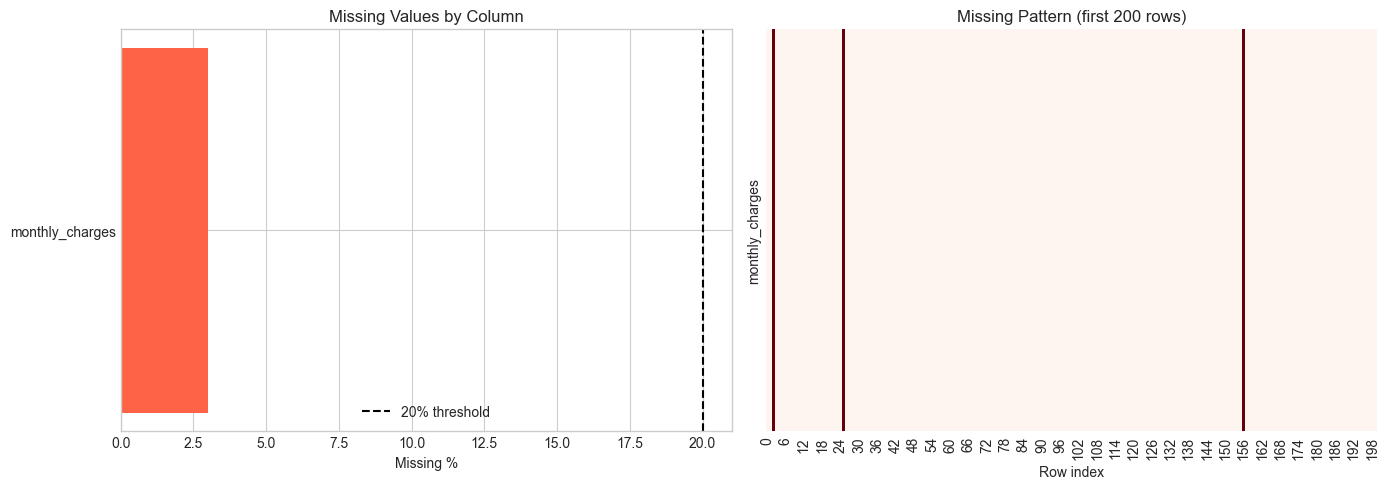

In [4]:
missing_result = check_missing_values(df, max_missing_pct=cfg['quality']['max_missing_pct'])

if missing_result['summary'].empty:
    print('✓ No missing values found.')
else:
    print('Missing value report:')
    display(missing_result['summary'])
    print(f"\nSuggestion: {missing_result['suggestion']}")

plot_missing_heatmap(df)

## 3. Outlier Detection

In [5]:
outlier_result = check_outliers(
    df,
    numeric_cols=[c for c in NUMERIC_COLS if c in df.columns],
    max_outlier_pct=cfg['quality']['max_outlier_pct'],
    method='iqr',
)

outlier_df = pd.DataFrame(outlier_result['details']).T
print('Outlier summary:')
display(outlier_df.sort_values('outlier_pct', ascending=False))
print(f"\nSuggestion: {outlier_result['suggestion']}")

Outlier summary:


,outlier_count,outlier_pct,violation,min,max
charge_per_tenure,145,7.25,True,0.2903,109.99
support_intensity,139,6.95,True,0.0,4.0
product_density,115,5.75,True,0.0141,5.0
support_calls_3m,33,1.65,False,0.0,46.0
age,0,0.0,False,18.0,74.0
tenure_months,0,0.0,False,1.0,71.0
monthly_charges,0,0.0,False,20.04,110.0
total_charges,0,0.0,False,0.0,7772.93
num_products,0,0.0,False,1.0,5.0
avg_monthly_usage_3m,0,0.0,False,0.0,100.0



Suggestion: Investigate and cap/transform outlier columns


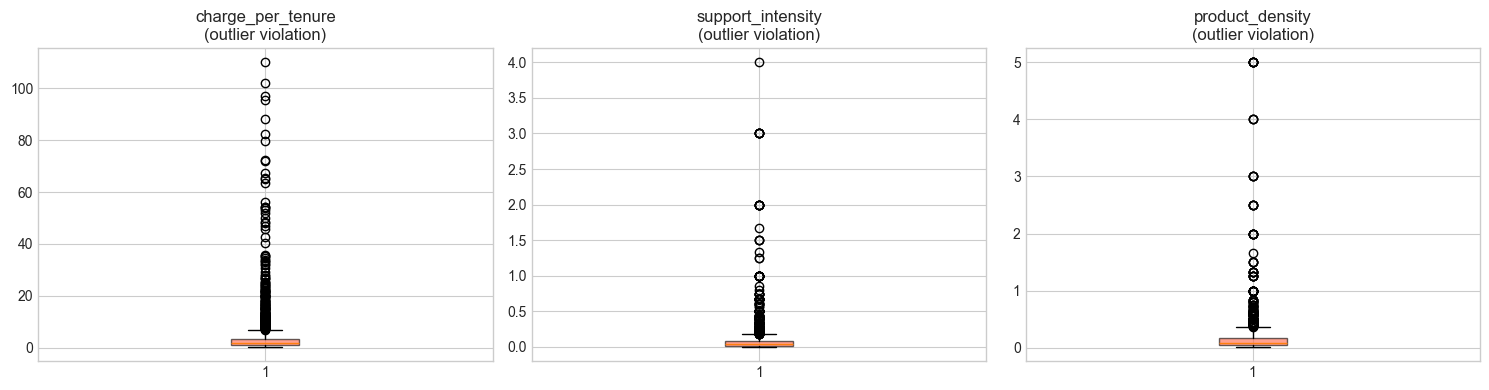

In [6]:
# Box plots for columns with violations
violating = [c for c, d in outlier_result['details'].items() if d.get('violation')]

if violating:
    fig, axes = plt.subplots(1, len(violating), figsize=(5 * len(violating), 4))
    if len(violating) == 1:
        axes = [axes]
    for ax, col in zip(axes, violating):
        ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='tomato', alpha=0.6))
        ax.set_title(f'{col}\n(outlier violation)')
    plt.tight_layout()
    plt.show()
else:
    print('✓ No outlier violations.')

## 4. Feature Distributions

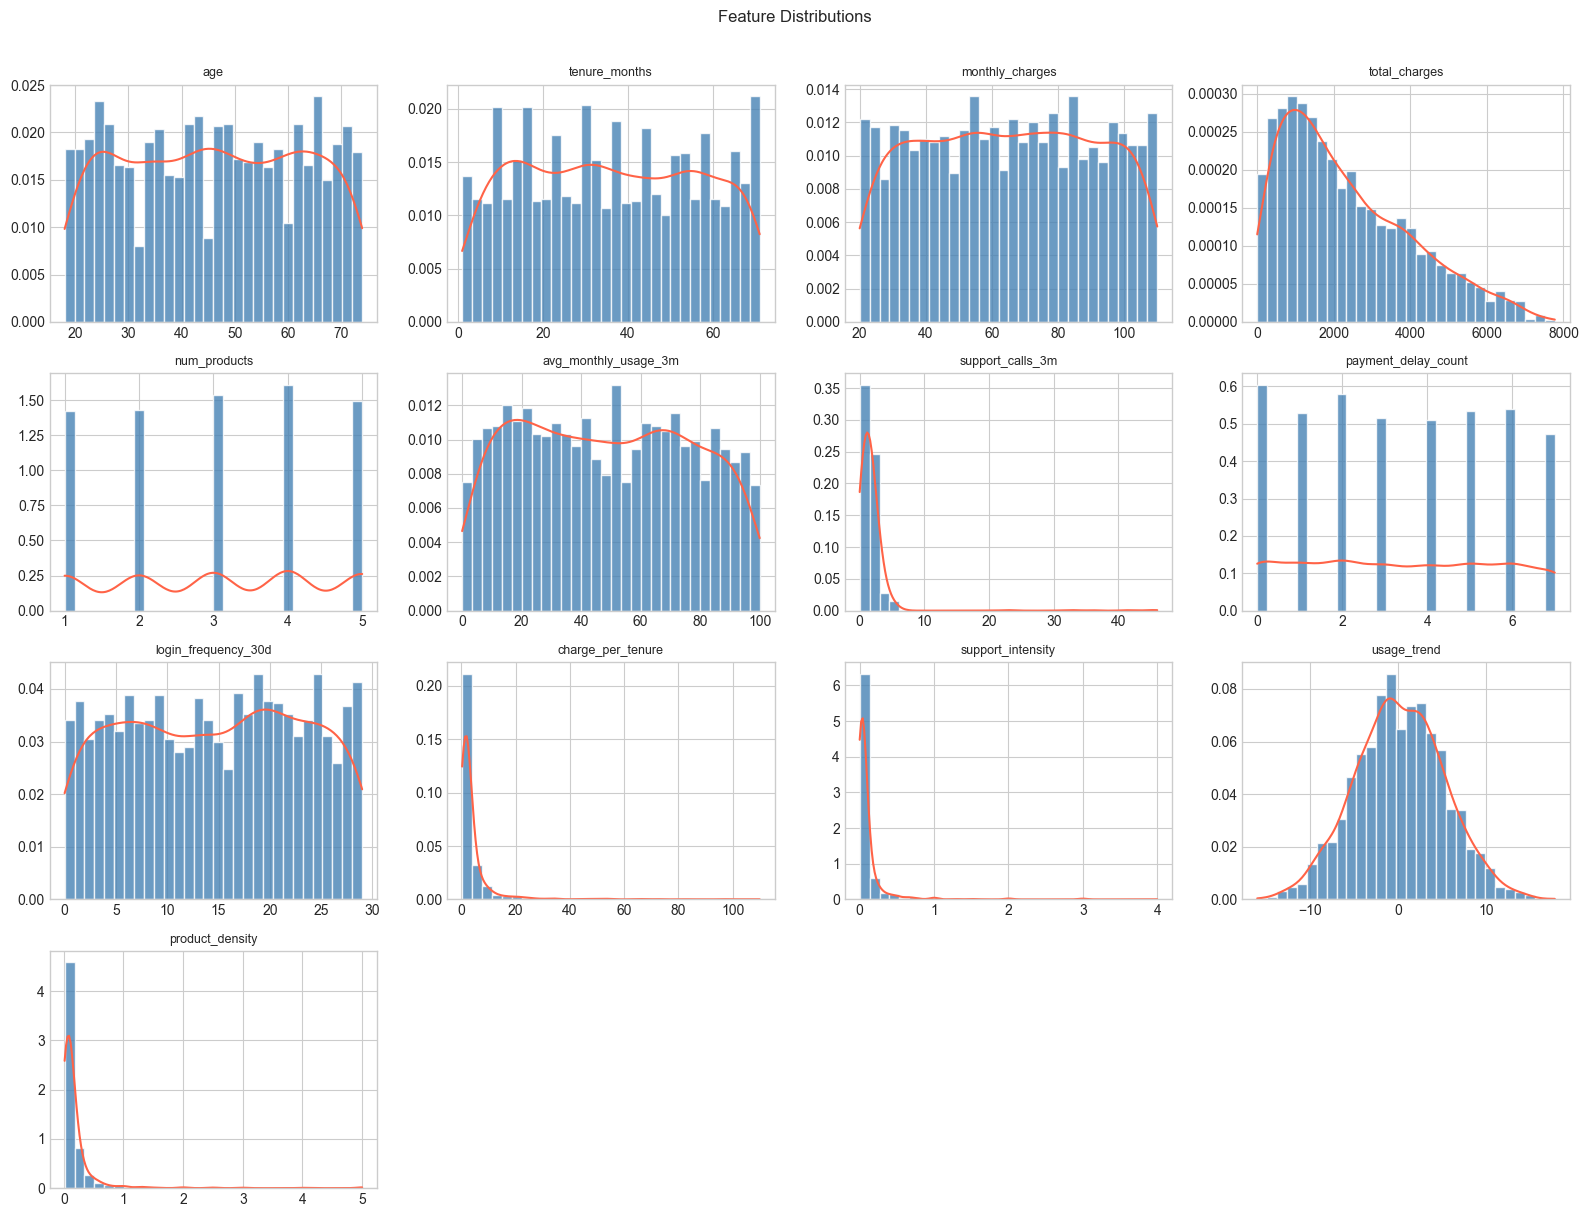

In [7]:
plot_distributions(df, [c for c in NUMERIC_COLS if c in df.columns], cols_per_row=4)

## 5. Categorical Feature Distributions

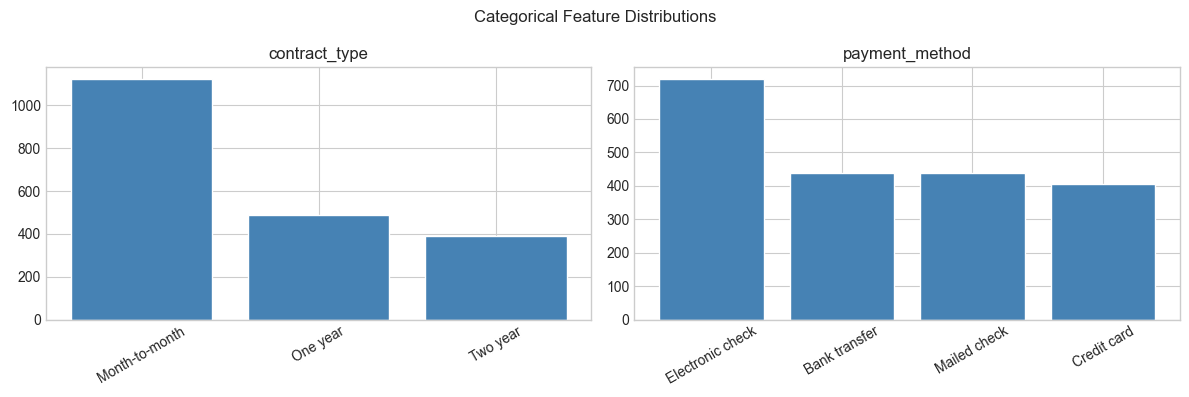

In [8]:
cat_cols = [c for c in cfg['categorical_features'] if c in df.columns]
fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)

plt.suptitle('Categorical Feature Distributions', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

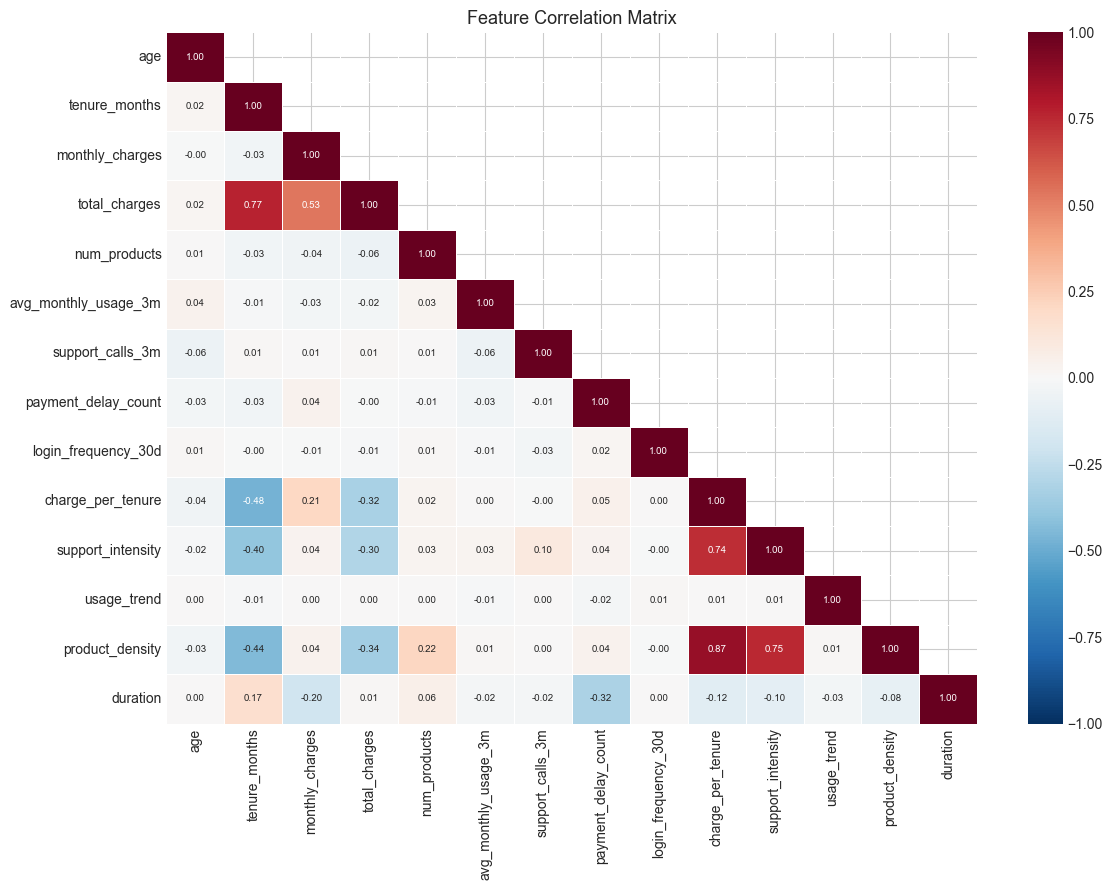


Correlation with duration (↑ = potential leakage):
payment_delay_count     0.317569
monthly_charges         0.198753
tenure_months           0.166387
charge_per_tenure       0.116980
support_intensity       0.100174
product_density         0.083394
num_products            0.056534
usage_trend             0.025574
support_calls_3m        0.023248
avg_monthly_usage_3m    0.017540


In [9]:
num_cols_present = [c for c in NUMERIC_COLS + [DURATION_COL] if c in df.columns]
corr = df[num_cols_present].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
    annot_kws={'size': 7}
)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# Highlight high correlations with duration (potential leakage)
target_corr = corr[DURATION_COL].drop(DURATION_COL).abs().sort_values(ascending=False)
print('\nCorrelation with duration (↑ = potential leakage):')
print(target_corr.head(10).to_string())

## 7. Full Quality Report

In [10]:
report = run_all_checks(df, cfg)
print_report(report)


  DATA QUALITY REPORT

  [✓] SCHEMA
       → Schema OK

  [✓] MISSING_VALUES
       → Missing values within acceptable limits

  [✗] OUTLIERS
       → Investigate and cap/transform outlier columns

  [✗] SURVIVAL_CONSISTENCY
       → Fix issues above

  [✓] DATA_LEAKAGE
       → No obvious leakage detected

  [✓] MINIMUM_SAMPLES
       → Sample size OK (2,000 rows)

  Result : REJECTED ✗ — fix issues before proceeding
  Score  : 4/6 checks passed



## 8. Save Quality Flag

In [11]:
import json

flag = {
    'approved': report['approved'],
    'verdict': report['verdict'],
    'n_passed': report['n_passed'],
    'n_total': report['n_total'],
}

flag_path = DATA_RAW / 'quality_flag.json'
with open(flag_path, 'w') as f:
    json.dump(flag, f, indent=2)

print(f'Quality flag saved → {flag_path}')

if not report['approved']:
    print('\n⚠️  Dataset NOT approved. Fix the issues above before running notebook 03.')
else:
    print('\n✓ Dataset approved. Proceed to 03_feature_engineering.ipynb')

Quality flag saved → /Users/ana/Documents/survival-analysis-pipelines/data/raw/quality_flag.json

⚠️  Dataset NOT approved. Fix the issues above before running notebook 03.
